## Image Classification on cars dataset

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

## Loading dataset

In [5]:
TRAIN_PATH = "/kaggle/input/datasets/kshitij192/cars-image-dataset/Cars Dataset/train"
TEST_PATH  = "/kaggle/input/datasets/kshitij192/cars-image-dataset/Cars Dataset/test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=(224,224),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=(224,224),
    batch_size=32
)

print(train_ds.class_names)

Found 3352 files belonging to 7 classes.
Found 813 files belonging to 7 classes.
['Audi', 'Hyundai Creta', 'Mahindra Scorpio', 'Rolls Royce', 'Swift', 'Tata Safari', 'Toyota Innova']


## Model architecture (Building 🏋️)

In [8]:
num_classes = len(train_ds.class_names)

cnn_model = models.Sequential([

    # Block 1
    layers.Conv2D(32, (4,4), strides=2, activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(pool_size=(2,2)),

    # Block 2
    layers.Conv2D(64, (4,4), strides=2, activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),

    # Block 3
    layers.Conv2D(128, (4,4), strides=2, activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),

    # Flatten
    layers.Flatten(),

    # first Dense Layer
    layers.Dense(50, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
]) 

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 💪 Model training 

In [10]:
history = cnn_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15
)

Epoch 1/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 257ms/step - accuracy: 0.2464 - loss: 6.5879 - val_accuracy: 0.3567 - val_loss: 1.7588
Epoch 2/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 25s 242ms/step - accuracy: 0.3641 - loss: 1.7307 - val_accuracy: 0.4293 - val_loss: 1.6037
Epoch 3/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 41s 239ms/step - accuracy: 0.4494 - loss: 1.5578 - val_accuracy: 0.4588 - val_loss: 1.5471
Epoch 4/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 24s 232ms/step - accuracy: 0.5445 - loss: 1.2935 - val_accuracy: 0.5474 - val_loss: 1.3714
Epoch 5/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 223ms/step - accuracy: 0.6461 - loss: 1.0170 - val_accuracy: 0.5818 - val_loss: 1.3453
Epoch 6/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 24s 232ms/step - accuracy: 0.7513 - loss: 0.7321 - val_accuracy: 0.6052 - val_loss: 1.4123
Epoch 7/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 24s 224ms/step - accuracy: 0.8101 - loss: 0.5544 - val_accuracy: 0.6113 - val_loss: 1.5941
Epoch 8/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 41s 225ms/step - accuracy: 0.8751 - loss: 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


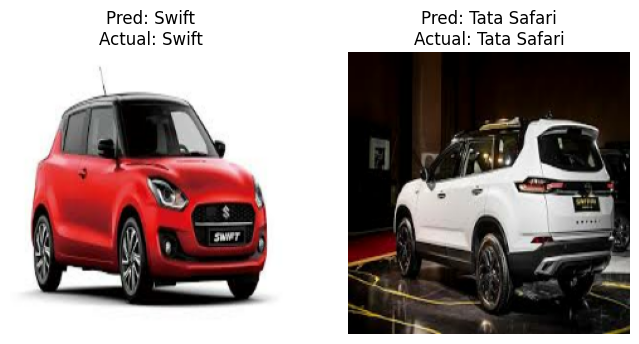

In [19]:
class_names = train_ds.class_names

for images, labels in test_ds.take(1):

    sample_images = tf.gather(images, [2, 4])
    sample_labels = tf.gather(labels, [2, 4])

    preds = cnn_model.predict(sample_images)
    pred_labels = np.argmax(preds, axis=1)

    plt.figure(figsize=(8,4))

    for i in range(2):
        plt.subplot(1,2,i+1)
        plt.imshow(sample_images[i].numpy().astype("uint8"))
        plt.title(
            f"Pred: {class_names[pred_labels[i]]}\n"
            f"Actual: {class_names[sample_labels[i]]}"
        )
        plt.axis("off")

    plt.show()